In [88]:
from IPython.display import Markdown, display
title = "Torque Analysis"
authors = "Hugo Duchemin"
display(Markdown(f"# {title}"))
display(Markdown(f"by {authors}"))

# Torque Analysis

by Hugo Duchemin

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# We load the data and make a loop to run different participants easier in the future 

In [90]:
sub = '001'
ses = '001'
path = f'/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh'


# The first step is to verify whether the participants followed the protocol correctly

   -0.83047456
0    -0.830475
1    -0.254423
2    -0.350431
3    -0.542449
4    -0.110410


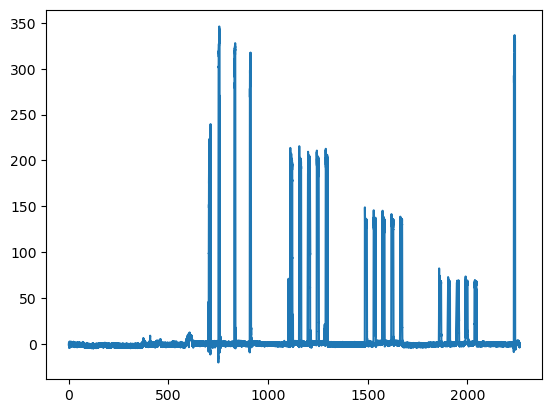

In [91]:
# Load the data from the torque_physio.tsv.gz file
torque_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_physio.tsv.gz', sep='\t', compression='gzip')
# Display the key information about the data
print (torque_data.head())
# let's plot to see what it looks like
fs = 500  # Sampling frequency in Hz
torque_data['time'] = torque_data.index / fs  # Create a time column based on the index and sampling frequency
plt.plot(torque_data['time'], torque_data.iloc[:, 0])  # Plot the first column of torque data against time


In [92]:
# Load the data events from the events.tsv file
events_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_events.tsv', sep='\t')
# Display the header of the events data
print("Events Data Columns:", events_data.columns)
print("First 5 Rows of Events Data:\n", events_data.head())

Events Data Columns: Index(['onset', 'duration', 'trial_type'], dtype='object')
First 5 Rows of Events Data:
         onset  duration       trial_type
0   68.895262         0  Occlusion_Start
1  369.112185         0    Occlusion_End
2  633.179443         0     Warmup_Start
3  734.497236         0       Warmup_End
4  747.212569         0  Start_MVC_Pre_1


### Observation : We can see 3 headers (onset, duration and trial type)
- **onset** = precise time of the event (in seconds) 
- **duration** = temporal point (instantanneous) 
- **trial type** = name of the event 

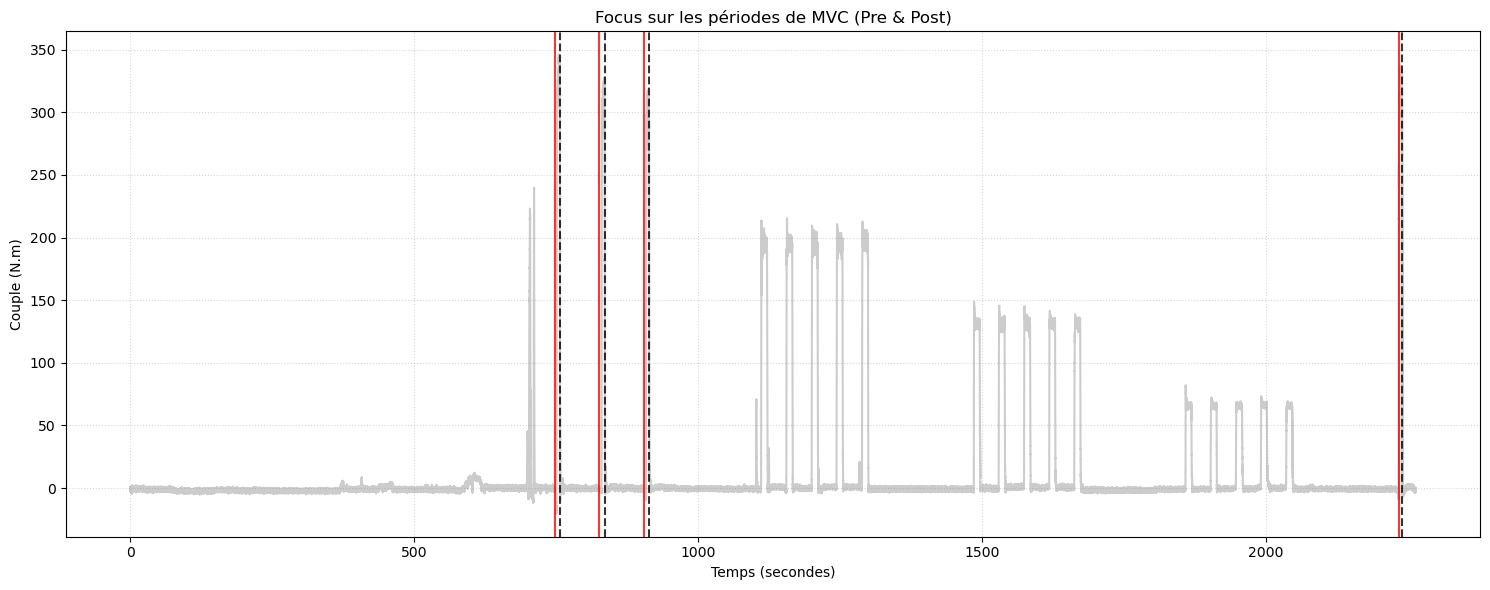

In [93]:
plt.figure(figsize=(15, 6))

# we plot the torque data in gray with some transparency
plt.plot(torque_data['time'], torque_data.iloc[:, 0], label='Torque (N.m)', color='gray', alpha=0.4)

# we iterate through the events data to find the relevant events and plot vertical lines
for index, row in events_data.iterrows():
    name = row['trial_type']
    onset = row['onset']
    
    # we define the conditions for start and stop events based on the trial_type
    is_start = 'Start_MVC' in name
    is_stop = 'Stop_Force' in name or 'Stop_MVC_Post' in name
    
    if is_start or is_stop:
        # color and linestyle for start and stop events
        color = 'red' if is_start else 'black'
        linestyle = '-' if is_start else '--'
        
        # we plot a vertical line at the onset of the event
        plt.axvline(x=onset, color=color, linestyle=linestyle, alpha=0.8)
        
plt.xlabel('Temps (secondes)')
plt.ylabel('Couple (N.m)')
plt.title('Focus sur les périodes de MVC (Pre & Post)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

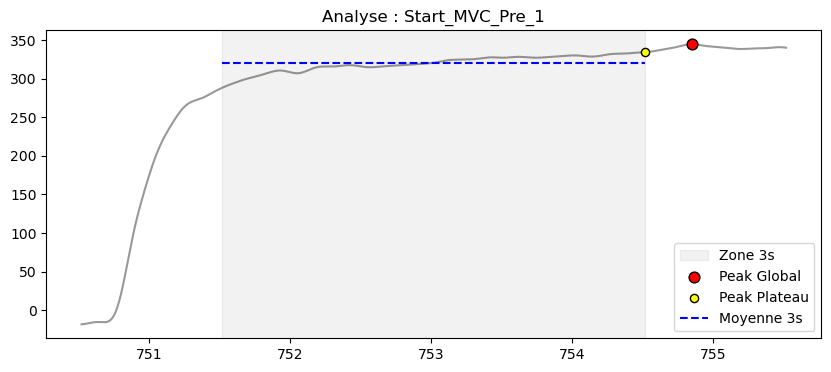

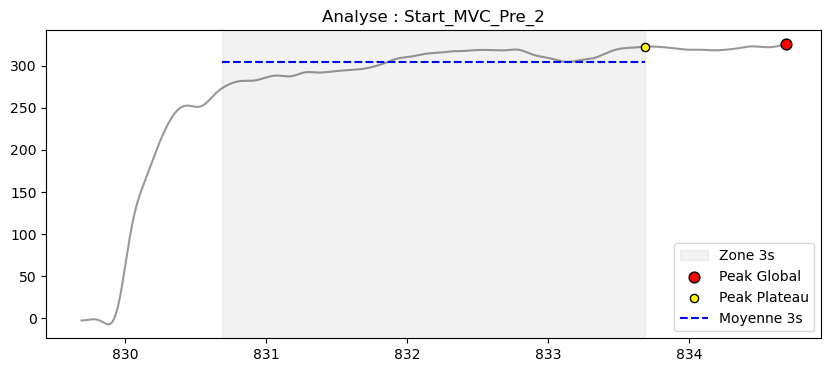

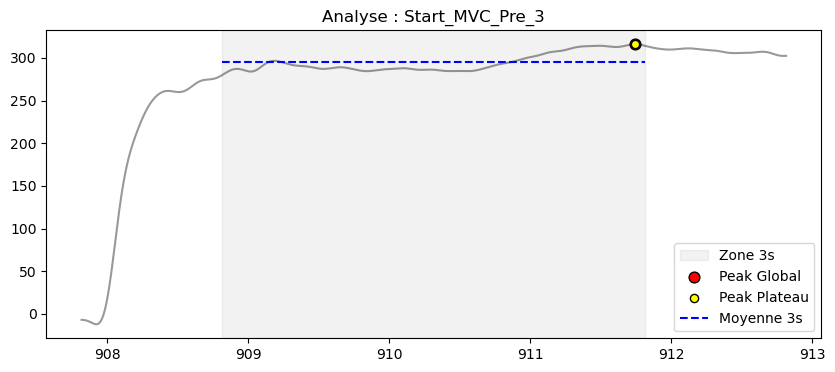

Note: Onset_Force non trouvé pour Start_MVC_Post, utilisation du début du label.


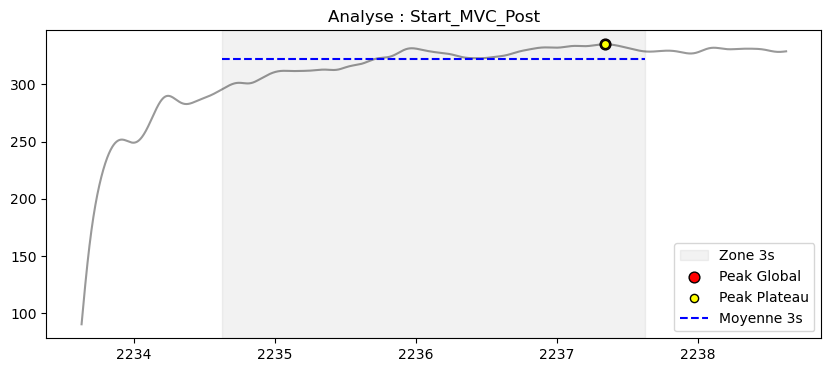


--- Tableau Récapitulatif Final ---
               MVC  Peak_Global  Peak_Plateau_3s     Mean_3s
0  Start_MVC_Pre_1   344.676371       334.530795  319.863390
1  Start_MVC_Pre_2   325.456469       322.576594  304.700342
2  Start_MVC_Pre_3   315.943673       315.943673  294.640348
3   Start_MVC_Post   335.142694       335.142694  322.340305


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. CONFIGURATION ET FILTRAGE ---
fs = 500  # Fréquence d'échantillonnage mise à jour
cutoff = 200 

def lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# On filtre le torque au début
torque_data.iloc[:, 0] = lowpass_filter(torque_data.iloc[:, 0], cutoff, fs)

# --- 2. ANALYSE DES MVC ---
mvc_labels = ['Start_MVC_Pre_1', 'Start_MVC_Pre_2', 'Start_MVC_Pre_3', 'Start_MVC_Post']
mvc_results = []

for label in mvc_labels:
    try:
        # 1. Trouver l'index du label actuel
        idx_label = events_data.index[events_data['trial_type'] == label][0]
        t_start_event = events_data.loc[idx_label, 'onset']
        
        # 2. Chercher Onset_Force APRÈS ce label
        following_events = events_data.iloc[idx_label:]
        onset_force_list = following_events[following_events['trial_type'] == 'Onset_Force']
        
        if not onset_force_list.empty:
            t_reference = onset_force_list.iloc[0]['onset']
        else:
            # Sécurité pour le Post MVC si Onset_Force est manquant
            t_reference = t_start_event
            print(f"Note: Onset_Force non trouvé pour {label}, utilisation du début du label.")

        # 3. Fenêtre de 5 secondes
        t_end_5s = t_reference + 5
        # Vérification si t_end_5s dépasse la fin du fichier
        t_end_5s = min(t_end_5s, torque_data['time'].max())
        
        segment_5s = torque_data[(torque_data['time'] >= t_reference) & (torque_data['time'] <= t_end_5s)].copy()
        
        # 4. Fenêtre de 3 secondes du milieu (T+1s à T+4s)
        t_mean_start = t_reference + 1.0
        t_mean_end = t_reference + 4.0
        
        # Sécurité si le segment est trop court à la fin du fichier
        if t_mean_end > segment_5s['time'].max():
            t_mean_end = segment_5s['time'].max()
            t_mean_start = max(t_reference, t_mean_end - 3.0)

        segment_3s = segment_5s[(segment_5s['time'] >= t_mean_start) & (segment_5s['time'] <= t_mean_end)].copy()
        
        # --- CALCULS ---
        peak_5s_val = segment_5s.iloc[:, 0].max()
        peak_5s_time = segment_5s.loc[segment_5s.iloc[:, 0].idxmax(), 'time']
        
        peak_3s_val = segment_3s.iloc[:, 0].max()
        peak_3s_time = segment_3s.loc[segment_3s.iloc[:, 0].idxmax(), 'time']
        
        mean_3s_val = segment_3s.iloc[:, 0].mean()
        
        mvc_results.append({
            'MVC': label, 
            'Peak_Global': peak_5s_val, 
            'Peak_Plateau_3s': peak_3s_val,
            'Mean_3s': mean_3s_val
        })
        
        # --- VISUALISATION ---
        plt.figure(figsize=(10, 4))
        plt.plot(segment_5s['time'], segment_5s.iloc[:, 0], color='black', alpha=0.4)
        plt.axvspan(t_mean_start, t_mean_end, color='gray', alpha=0.1, label='Zone 3s')
        
        plt.scatter(peak_5s_time, peak_5s_val, color='red', s=60, edgecolors='black', zorder=5, label='Peak Global')
        plt.scatter(peak_3s_time, peak_3s_val, color='yellow', s=35, edgecolors='black', zorder=6, label='Peak Plateau')
        plt.hlines(mean_3s_val, t_mean_start, t_mean_end, colors='blue', linestyles='--', label='Moyenne 3s')
        
        plt.title(f"Analyse : {label}")
        plt.legend(loc='best')
        plt.show()

    except Exception as e:
        print(f"Erreur pour {label}: {e}")

# --- 3. RÉSUMÉ ---
df_final = pd.DataFrame(mvc_results)
print("\n--- Tableau Récapitulatif Final ---")
print(df_final)

--- ANALYSE DE LA FATIGUE : PRE vs POST ---
Moyenne des 3 MVC Pre : 306.40 ± 12.70 N.m
Valeur MVC Post       : 322.34 N.m
Variation (Fatigue)   : 5.20 %
-------------------------------------------
Résultat Statistique :
t-stat = -2.174 | p-value = 0.1617
=> Résultat NON SIGNIFICATIF (p >= 0.05)


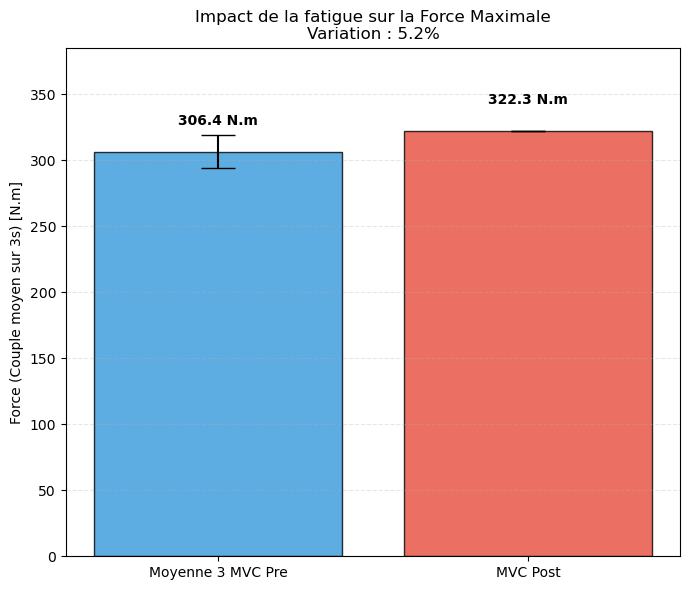

In [103]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# 1. Vérification et extraction des moyennes de plateau (3s)
# On s'assure que df_final contient bien les lignes Pre et Post
pre_data = df_final[df_final['MVC'].str.contains('Pre')]
post_data = df_final[df_final['MVC'].str.contains('Post')]

if len(pre_data) == 3 and len(post_data) == 1:
    pre_means = pre_data['Mean_3s'].values
    post_mean = post_data['Mean_3s'].values[0]

    # 2. Calcul de la moyenne et écart-type des 3 MVC Pre
    group_pre_avg = np.mean(pre_means)
    group_pre_std = np.std(pre_means, ddof=1) # ddof=1 pour l'écart-type échantillon

    # 3. Calcul du pourcentage de variation (Fatigue)
    percentage_change = ((post_mean - group_pre_avg) / group_pre_avg) * 100

    # 4. Test t de Student (One-sample)
    # On teste si la valeur Post est significativement différente de la distribution des Pre
    t_stat, p_val = stats.ttest_1samp(pre_means, post_mean)

    # --- AFFICHAGE DES RÉSULTATS ---
    print(f"--- ANALYSE DE LA FATIGUE : PRE vs POST ---")
    print(f"Moyenne des 3 MVC Pre : {group_pre_avg:.2f} ± {group_pre_std:.2f} N.m")
    print(f"Valeur MVC Post       : {post_mean:.2f} N.m")
    print(f"Variation (Fatigue)   : {percentage_change:.2f} %")
    print(f"-------------------------------------------")
    print(f"Résultat Statistique :")
    print(f"t-stat = {t_stat:.3f} | p-value = {p_val:.4f}")

    if p_val < 0.05:
        print("=> Résultat SIGNIFICATIF (p < 0.05)")
    else:
        print("=> Résultat NON SIGNIFICATIF (p >= 0.05)")

    # --- VISUALISATION ---
    plt.figure(figsize=(7, 6))
    
    labels = ['Moyenne 3 MVC Pre', 'MVC Post']
    values = [group_pre_avg, post_mean]
    errors = [group_pre_std, 0] # Pas d'erreur sur une mesure unique (Post)

    bars = plt.bar(labels, values, yerr=errors, capsize=12, 
                   color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.8)
    
    # Ajouter les étiquettes de valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + group_pre_std + 5,
                 f'{height:.1f} N.m', ha='center', va='bottom', fontweight='bold')

    plt.ylabel('Force (Couple moyen sur 3s) [N.m]')
    plt.title(f'Impact de la fatigue sur la Force Maximale\nVariation : {percentage_change:.1f}%')
    plt.ylim(0, max(values) + group_pre_std + 50) # Ajuste l'échelle Y
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print("Erreur : Le tableau df_final doit contenir exactement 3 essais 'Pre' et 1 essai 'Post'.")
    print(f"Actuellement : {len(pre_data)} Pre, {len(post_data)} Post.")